# Radial Velocity Dispersion Profile

Spatially-resolved stellar kinematics of the AGEL0206 deflector galaxy.

1. Find the deflector center from HST F140W imaging (isophote fitting)
2. Multi-Gaussian expansion (MGE) of the 2D light profile
3. Map IFU spaxels to radial distance from center
4. Bin spaxels by radius (annular rings + PowerBin)
5. Run ppxf on each radial bin → sigma(R) profile
6. Convert to physical units (kpc) and compare to literature

Inspired by Melo-Carneiro et al. (2025) analysis of the Cosmic Horseshoe.

**Target:** AGEL0206 deflector, z = 0.675  
**IFU:** Keck/KCWI medium slicer  
**Imaging:** HST WFC3/IR F140W (0.08"/pix)

## 1. Imports and data loading

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
from astropy.io import fits
from astropy.wcs import WCS
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
from photutils.isophote import EllipseGeometry, Ellipse as IsoEllipse, build_ellipse_model
from photutils.aperture import EllipticalAperture, CircularAnnulus
import sys
sys.path.insert(0, '..')

from time import perf_counter as clock
from importlib import resources
from urllib import request
from ppxf.ppxf import ppxf
import ppxf.ppxf_util as util
import ppxf.sps_util as lib
from tqdm import tqdm

plt.rcParams['figure.facecolor'] = 'white'
plt.rc('font', family='serif', size=14)
plt.rc('axes', linewidth=1.5, labelsize=16)
plt.rc('xtick', labelsize=14, direction='in')
plt.rc('ytick', labelsize=14, direction='in')

# Cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
z_defl = 0.675
d_A = cosmo.angular_diameter_distance(z_defl)
kpc_per_arcsec = d_A.to(u.kpc).value * np.pi / 180 / 3600
print(f'Angular diameter distance: {d_A:.1f}')
print(f'Scale: {kpc_per_arcsec:.2f} kpc/arcsec ({1/kpc_per_arcsec:.2f} arcsec/kpc)')

Angular diameter distance: 1452.3 Mpc
Scale: 7.04 kpc/arcsec (0.14 arcsec/kpc)


In [2]:
# Load IFU cube
ifu_file = '../Nov17_2025_DESJ0206_RL_combined_icubes_wcs.fits'
with fits.open(ifu_file) as hdul:
    hdr_ifu = hdul[0].header
    cube = np.asarray(hdul[0].data, dtype=float)

crval = hdr_ifu['CRVAL3']
cdelt = hdr_ifu['CD3_3']
npix = hdr_ifu['NAXIS3']
crpix = hdr_ifu.get('CRPIX3', 1.0)
pix = np.arange(npix)
lam = crval + cdelt * (pix + 1 - crpix)

print(f'IFU cube: {cube.shape}')
print(f'Wavelength: {lam[0]:.0f} - {lam[-1]:.0f} Å')

# Load HST F140W cutout + mask
hst_dir = '../../velocity_dispersion_from_IFU'
f140w_file = f'{hst_dir}/AGEL020613-011417A_F140W_WFC3_cutout_L3.fits'
f140w_mask_file = f'{hst_dir}/AGEL020613-011417A_F140W_WFC3_cutout_L3_mask.fits'

with fits.open(f140w_file) as hdul:
    hdr_f140 = hdul[0].header
    img_f140 = hdul[0].data
    wcs_f140 = WCS(hdr_f140)

try:
    with fits.open(f140w_mask_file) as hdul:
        mask_f140 = hdul[0].data.astype(bool)
    print(f'F140W mask loaded: {np.sum(mask_f140)} masked pixels')
except FileNotFoundError:
    mask_f140 = np.zeros_like(img_f140, dtype=bool)
    print('No mask file found — using no mask')

print(f'F140W image: {img_f140.shape}, pixel scale: ~0.08 arcsec/pix')

IFU cube: (3317, 100, 100)
Wavelength: 5625 - 8941 Å
F140W mask loaded: 1121 masked pixels
F140W image: (312, 312), pixel scale: ~0.08 arcsec/pix


## 2. Find deflector center via isophote fitting

Use photutils `Ellipse` to fit isophotes to the F140W cutout image.
The center of the innermost isophote gives the precise RA/Dec of the
deflector galaxy center.

In [3]:
# Initial center guess from known target RA/Dec (not image peak, which may hit a contaminant)
ra_target, dec_target = 31.55611, -1.23817
x0, y0 = wcs_f140.world_to_pixel_values(ra_target, dec_target)
x0, y0 = float(x0), float(y0)
print(f"Initial center from target coords (pixel): x={x0:.1f}, y={y0:.1f}")

# Apply mask: set contaminating sources to NaN so isophote fitter ignores them
img_masked = img_f140.copy()
img_masked[mask_f140] = np.nan
img_masked = np.nan_to_num(img_masked, nan=0.0)

# Refine center: find peak within a small box around the target position
from scipy.ndimage import gaussian_filter
img_smooth = gaussian_filter(img_masked, sigma=2)
box_half = 20  # pixels (~1.6 arcsec search radius)
iy0, ix0 = int(round(y0)), int(round(x0))
y_lo = max(0, iy0 - box_half)
y_hi = min(img_smooth.shape[0], iy0 + box_half)
x_lo = max(0, ix0 - box_half)
x_hi = min(img_smooth.shape[1], ix0 + box_half)
cutout = img_smooth[y_lo:y_hi, x_lo:x_hi]
dy, dx = np.unravel_index(np.argmax(cutout), cutout.shape)
x0 = x_lo + dx
y0 = y_lo + dy
print(f"Refined center (pixel): x={x0}, y={y0}")

# Convert to RA/Dec
ra0, dec0 = wcs_f140.pixel_to_world_values(x0, y0)
print(f"Refined center (RA, Dec): {ra0:.6f}, {dec0:.6f}")
print(f"Offset from target: dRA={3600*(ra0 - ra_target):.2f} arcsec, dDec={3600*(dec0 - dec_target):.2f} arcsec")

# Set up isophote fitting starting from the refined center
geometry = EllipseGeometry(x0=x0, y0=y0, sma=10, eps=0.2, pa=0)
ellipse = IsoEllipse(img_masked, geometry)

# Fit isophotes
try:
    isolist = ellipse.fit_image(maxsma=50, step=0.1, fix_center=False)
    print(f"Fit {len(isolist)} isophotes, sma range: {isolist.sma.min():.1f} - {isolist.sma.max():.1f} pix")
except Exception as e:
    print(f"Isophote fitting failed with free center: {e}")
    print("Trying with fixed center...")
    isolist = ellipse.fit_image(maxsma=50, step=0.1, fix_center=True)
    print(f"Fit {len(isolist)} isophotes (fixed center)")


Initial center from target coords (pixel): x=155.2, y=155.8
Refined center (pixel): x=154, y=155
Refined center (RA, Dec): 31.556084, -1.238189
Offset from target: dRA=-0.10 arcsec, dDec=-0.07 arcsec
Isophote fitting failed with free center: zero-size array to reduction operation minimum which has no identity
Trying with fixed center...
Fit 0 isophotes (fixed center)


Number of isophotes: 0
Isophote fitting produced no results — using refined pixel center
Fitted center (pixel): x=154.0, y=155.0
Median ellipticity: 0.200
Median PA: 0.0 deg
Deflector center: RA=31.556084, Dec=-1.238189
Offset from nominal: dRA=-0.10 arcsec, dDec=-0.07 arcsec


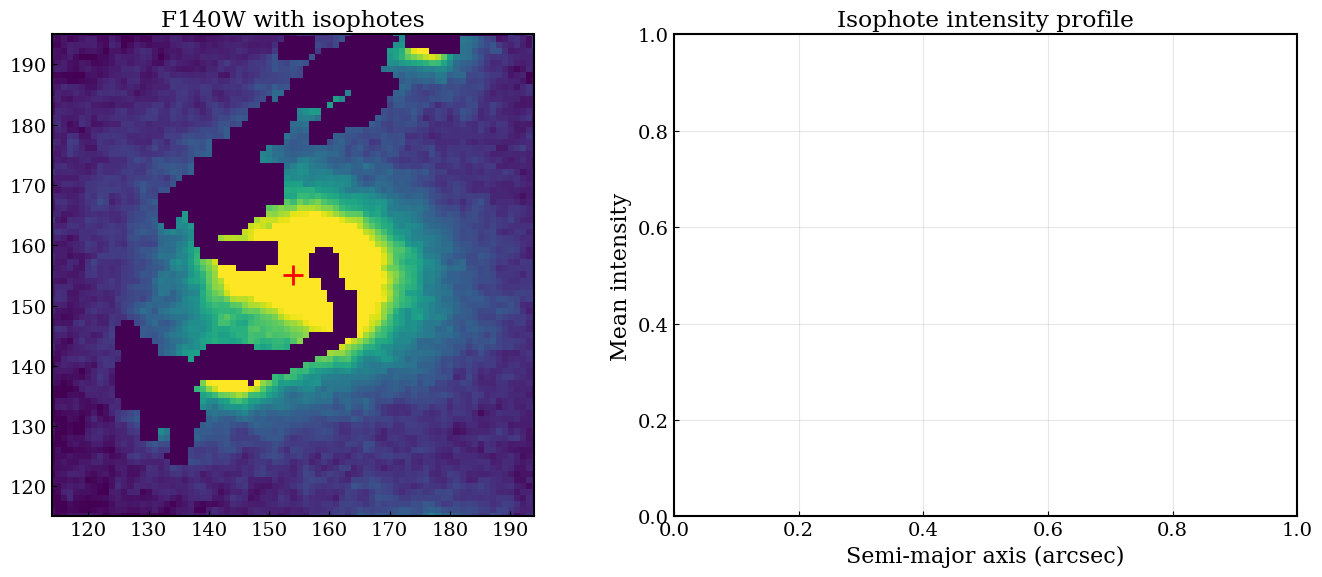

In [4]:
# Diagnostic: check what the isophote fitter returned
print(f"Number of isophotes: {len(isolist)}")
if len(isolist) > 0:
    print(f"SMA range: {isolist.sma.min():.1f} - {isolist.sma.max():.1f} pix")
    print(f"First 5 SMA values: {isolist.sma[:5]}")
    print(f"First 5 x0 values: {isolist.x0[:5]}")
    print(f"First 5 y0 values: {isolist.y0[:5]}")
else:
    print("WARNING: No isophotes returned!")

# Use all isophotes (or fall back to the refined pixel center)
if len(isolist) > 0 and np.any(np.isfinite(isolist.x0)):
    # Use isophotes that have valid centers
    valid = np.isfinite(isolist.x0) & np.isfinite(isolist.y0)
    if np.any(valid):
        x_center = np.median(isolist.x0[valid])
        y_center = np.median(isolist.y0[valid])
        eps_med = np.median(isolist.eps[valid])
        pa_med = np.median(isolist.pa[valid])
    else:
        print("No valid isophote centers — using refined pixel center")
        x_center, y_center = float(x0), float(y0)
        eps_med, pa_med = 0.2, 0.0
else:
    print("Isophote fitting produced no results — using refined pixel center")
    x_center, y_center = float(x0), float(y0)
    eps_med, pa_med = 0.2, 0.0

print(f"Fitted center (pixel): x={x_center:.1f}, y={y_center:.1f}")
print(f"Median ellipticity: {eps_med:.3f}")
print(f"Median PA: {np.degrees(pa_med):.1f} deg")

# Convert to RA/Dec
ra_center, dec_center = wcs_f140.pixel_to_world_values(x_center, y_center)
print(f"Deflector center: RA={ra_center:.6f}, Dec={dec_center:.6f}")
print(f"Offset from nominal: dRA={3600*(ra_center - 31.55611):.2f} arcsec, dDec={3600*(dec_center - (-1.23817)):.2f} arcsec")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
vmin, vmax = np.nanpercentile(img_f140[img_f140 > 0], [1, 99])
ax.imshow(img_masked, origin="lower", cmap="viridis", vmin=vmin, vmax=vmax)
ax.plot(x_center, y_center, "r+", markersize=15, markeredgewidth=2)
if len(isolist) > 0:
    for iso in isolist[::5]:
        if iso.sma > 0 and iso.eps < 1:
            aper = EllipticalAperture((iso.x0, iso.y0), iso.sma, iso.sma*(1-iso.eps), iso.pa)
            aper.plot(ax=ax, color="white", lw=0.5)
ax.set_title("F140W with isophotes")
ax.set_xlim(x_center - 40, x_center + 40)
ax.set_ylim(y_center - 40, y_center + 40)

ax = axes[1]
if len(isolist) > 0:
    ax.plot(isolist.sma * 0.08, isolist.intens, "k-o", markersize=3)
    ax.set_yscale("log")
ax.set_xlabel("Semi-major axis (arcsec)")
ax.set_ylabel("Mean intensity")
ax.set_title("Isophote intensity profile")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 3. MGE decomposition from isophote profile

Decompose the 1D intensity profile into a sum of Gaussians.
This gives a smooth parametric model of the light distribution.

Isophote data insufficient — building profile from circular apertures
Built profile from 24 annuli
MGE fit (3 Gaussians):
  Component 1: A=1.03, sigma=0.174 arcsec (1.23 kpc)
  Component 2: A=0.69, sigma=0.879 arcsec (6.19 kpc)
  Component 3: A=0.14, sigma=3.444 arcsec (24.25 kpc)


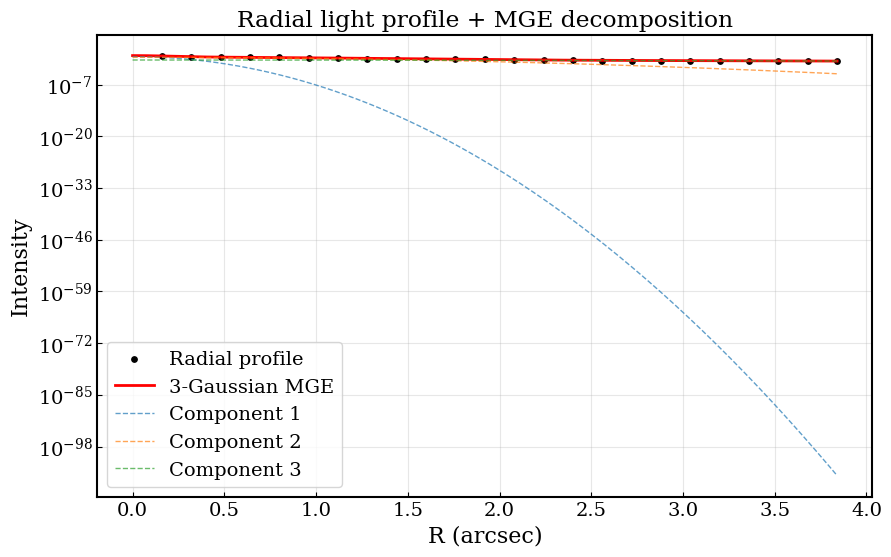

In [5]:
# Build 1D radial light profile and fit MGE
# If isophotes worked, use those. Otherwise, build from circular aperture photometry.
from scipy.optimize import curve_fit
from photutils.aperture import CircularAnnulus, CircularAperture, ApertureStats

def multi_gaussian_1d(r, *params):
    """Sum of N Gaussians: params = [A1, sigma1, A2, sigma2, ...]"""
    n_gauss = len(params) // 2
    result = np.zeros_like(r, dtype=float)
    for i in range(n_gauss):
        A = params[2*i]
        sigma = params[2*i + 1]
        result += A * np.exp(-r**2 / (2 * sigma**2))
    return result

# Try isophote data first
use_isophotes = (len(isolist) > 0 and np.sum(np.isfinite(isolist.intens) & (isolist.intens > 0)) > 5)

if use_isophotes:
    r_arcsec = isolist.sma * 0.08
    intensity = isolist.intens
    valid = np.isfinite(intensity) & (intensity > 0) & (r_arcsec > 0)
    r_fit = r_arcsec[valid]
    I_fit = intensity[valid]
    print(f"Using isophote data: {len(r_fit)} valid points")
else:
    # Fallback: circular aperture photometry from the image
    print("Isophote data insufficient — building profile from circular apertures")
    r_edges_ap = np.arange(1, 50, 2)  # radii in pixels
    r_fit_list = []
    I_fit_list = []
    for j in range(len(r_edges_ap) - 1):
        aper = CircularAnnulus((x_center, y_center), r_in=r_edges_ap[j], r_out=r_edges_ap[j+1])
        stats = ApertureStats(img_masked, aper)
        if np.isfinite(stats.mean) and stats.mean > 0:
            r_fit_list.append((r_edges_ap[j] + r_edges_ap[j+1]) / 2 * 0.08)  # pix to arcsec
            I_fit_list.append(stats.mean)
    r_fit = np.array(r_fit_list)
    I_fit = np.array(I_fit_list)
    print(f"Built profile from {len(r_fit)} annuli")

if len(r_fit) < 3:
    print("WARNING: Too few radial data points for MGE fit")
    popt = None
else:
    # Try 3-Gaussian fit
    n_gauss = 3
    p0 = []
    for i in range(n_gauss):
        p0.extend([I_fit[0] * 0.5**(i), 0.3 * (3**i)])
    
    bounds_lo = [0] * (2 * n_gauss)
    bounds_hi = [np.inf, 10.0] * n_gauss
    
    try:
        popt, pcov = curve_fit(multi_gaussian_1d, r_fit, I_fit, p0=p0,
                                bounds=(bounds_lo, bounds_hi), maxfev=10000)
        
        print(f"MGE fit ({n_gauss} Gaussians):")
        for i in range(n_gauss):
            print(f"  Component {i+1}: A={popt[2*i]:.2f}, sigma={popt[2*i+1]:.3f} arcsec ({popt[2*i+1]*kpc_per_arcsec:.2f} kpc)")
    except Exception as e:
        print(f"MGE fit failed: {e}")
        popt = None

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(r_fit, I_fit, c="k", s=15, label="Radial profile")
if popt is not None:
    r_model = np.linspace(0, r_fit.max(), 200)
    ax.plot(r_model, multi_gaussian_1d(r_model, *popt), "r-", lw=2, label=f"{n_gauss}-Gaussian MGE")
    for i in range(n_gauss):
        comp = popt[2*i] * np.exp(-r_model**2 / (2 * popt[2*i+1]**2))
        ax.plot(r_model, comp, "--", lw=1, alpha=0.7, label=f"Component {i+1}")
ax.set_xlabel("R (arcsec)")
ax.set_ylabel("Intensity")
ax.set_yscale("log")
ax.legend()
ax.set_title("Radial light profile + MGE decomposition")
ax.grid(alpha=0.3)
plt.show()


## 4. Map IFU spaxels to radial distance

Use the IFU cube WCS to compute the RA/Dec of each spaxel center,
then calculate angular and physical distance from the deflector center.

Spaxel grid: 19 x 10
Radial range: 0.13 - 3.25 arcsec
              0.9 - 22.9 kpc


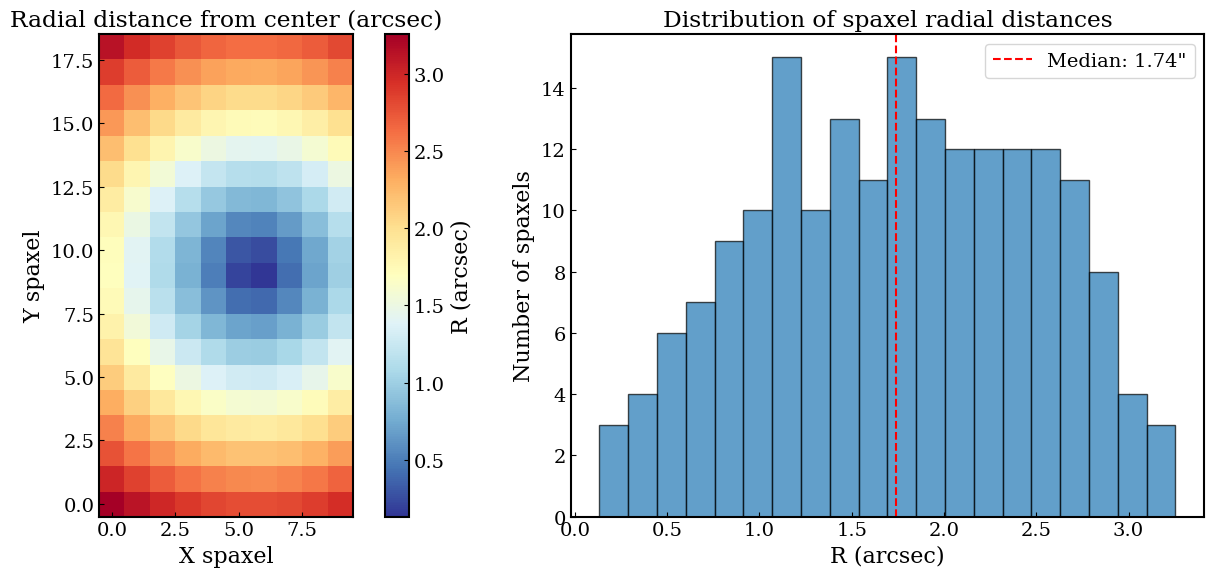

In [6]:
# IFU spatial WCS (axes 1 and 2 of the 3D cube)
wcs_ifu = WCS(hdr_ifu, naxis=2)

# Deflector spaxel region
y_slice = slice(45, 64)  # 19 spaxels
x_slice = slice(45, 55)  # 10 spaxels
ny, nx = 19, 10

# Compute RA/Dec for each spaxel center
yy, xx = np.mgrid[y_slice.start:y_slice.stop, x_slice.start:x_slice.stop]
ra_spax, dec_spax = wcs_ifu.pixel_to_world_values(xx.ravel(), yy.ravel())
ra_spax = ra_spax.reshape(ny, nx)
dec_spax = dec_spax.reshape(ny, nx)

# Angular distance from deflector center (arcsec)
dra = (ra_spax - ra_center) * np.cos(np.radians(dec_center)) * 3600  # arcsec
ddec = (dec_spax - dec_center) * 3600  # arcsec
r_arcsec_spax = np.sqrt(dra**2 + ddec**2)
r_kpc_spax = r_arcsec_spax * kpc_per_arcsec

print(f'Spaxel grid: {ny} x {nx}')
print(f'Radial range: {r_arcsec_spax.min():.2f} - {r_arcsec_spax.max():.2f} arcsec')
print(f'              {r_kpc_spax.min():.1f} - {r_kpc_spax.max():.1f} kpc')

# Plot spaxel positions and radial distances
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# White-light with radial distance overlay
whitelight = np.sum(cube[:, y_slice, x_slice], axis=0)
im = axes[0].imshow(r_arcsec_spax, origin='lower', cmap='RdYlBu_r')
axes[0].set_title('Radial distance from center (arcsec)')
axes[0].set_xlabel('X spaxel')
axes[0].set_ylabel('Y spaxel')
plt.colorbar(im, ax=axes[0], label='R (arcsec)')

# Histogram of radial distances
axes[1].hist(r_arcsec_spax.ravel(), bins=20, edgecolor='k', alpha=0.7)
axes[1].set_xlabel('R (arcsec)')
axes[1].set_ylabel('Number of spaxels')
axes[1].set_title('Distribution of spaxel radial distances')
axes[1].axvline(np.median(r_arcsec_spax), color='r', ls='--', label=f'Median: {np.median(r_arcsec_spax):.2f}"')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5a. Radial binning: annular rings

Average spaxel spectra within concentric annuli at fixed arcsec intervals.

In [7]:
# Define annular bins
r_edges = np.arange(0, r_arcsec_spax.max() + 0.5, 0.5)  # 0.5 arcsec bins
n_annuli = len(r_edges) - 1

# Extract spectra for each annulus
annular_spectra = []
annular_r_mid = []
annular_n_spax = []

# Noise from sky region
noise_sky = np.std(cube[:, 28:40, 45:70], axis=(1, 2))

for i in range(n_annuli):
    r_lo, r_hi = r_edges[i], r_edges[i+1]
    mask = (r_arcsec_spax >= r_lo) & (r_arcsec_spax < r_hi)
    n_in = np.sum(mask)
    
    if n_in < 2:
        continue
    
    # Average spectra of spaxels in this annulus
    # mask is (ny, nx), cube deflector region is (nwave, ny, nx)
    defl_cube = cube[:, y_slice, x_slice]
    spec_sum = np.average(defl_cube[:, mask], axis=1)
    
    annular_spectra.append(spec_sum)
    annular_r_mid.append((r_lo + r_hi) / 2)
    annular_n_spax.append(n_in)

annular_r_mid = np.array(annular_r_mid)
annular_n_spax = np.array(annular_n_spax)

print(f'Created {len(annular_spectra)} annular bins')
for i, (r, n) in enumerate(zip(annular_r_mid, annular_n_spax)):
    print(f'  Bin {i}: R={r:.2f}", {n} spaxels')

Created 7 annular bins
  Bin 0: R=0.25", 9 spaxels
  Bin 1: R=0.75", 26 spaxels
  Bin 2: R=1.25", 39 spaxels
  Bin 3: R=1.75", 42 spaxels
  Bin 4: R=2.25", 38 spaxels
  Bin 5: R=2.75", 32 spaxels
  Bin 6: R=3.25", 4 spaxels


## 5b. Radial binning: PowerBin with radial ordering

In [8]:
from powerbin import PowerBin

# Use a wider spatial region for PowerBin (same as notebook 01 section 5)
cube_wide = cube[:, 35:75, 30:70]
data_collapsed = np.average(cube_wide, axis=0)
noise_pb = np.median(np.std(cube[:, 28:40, 45:70], axis=(1, 2)))

xp, yp = np.arange(cube_wide.shape[1]), np.arange(cube_wide.shape[2])
xx_pb, yy_pb = np.meshgrid(xp, yp)
xy_pb = np.column_stack([xx_pb.ravel(), yy_pb.ravel()])

signal_flat = data_collapsed.ravel()
noise_flat = np.ones_like(signal_flat) * noise_pb

target_sn = 10

def capacity_spec(index):
    sn = np.sum(signal_flat[index]) / np.sqrt(np.sum(noise_flat[index]**2))
    return sn**2

pow_bins = PowerBin(xy_pb, capacity_spec, target_capacity=target_sn**2)
n_bins_pb = len(pow_bins.npix)

# Compute radial distance for each PowerBin
powerbin_idxs = pow_bins.bin_num
powerbin_idx_map = np.reshape(powerbin_idxs, data_collapsed.shape)

# Get RA/Dec for the wider region
yy_w, xx_w = np.mgrid[35:75, 30:70]
ra_w, dec_w = wcs_ifu.pixel_to_world_values(xx_w.ravel(), yy_w.ravel())
ra_w = ra_w.reshape(40, 40)
dec_w = dec_w.reshape(40, 40)

dra_w = (ra_w - ra_center) * np.cos(np.radians(dec_center)) * 3600
ddec_w = (dec_w - dec_center) * 3600
r_w = np.sqrt(dra_w**2 + ddec_w**2)

pb_r_mean = np.zeros(n_bins_pb)
for b in range(n_bins_pb):
    pb_r_mean[b] = np.mean(r_w[powerbin_idx_map == b])

print(f'PowerBin: {n_bins_pb} bins, target S/N={target_sn}')
print(f'Radial range: {pb_r_mean.min():.2f} - {pb_r_mean.max():.2f} arcsec')

Bin-accretion Delaunay...
25  initial bins.
25  good bins.
Regularization...
Bins: 25; Single Pixels: 0/1600
Capacity Fractional RMS Scatter (%): 46.20
Time Accretion: 0.04 s
Time Regularization (it=44): 0.06 s
PowerBin: 25 bins, target S/N=10
Radial range: 0.25 - 6.26 arcsec


## 6. Run ppxf on radial bins

Fit each radial bin (both annular and PowerBin) with ppxf across
multiple polynomial degrees, using the same approach as notebook 01.

In [15]:
# ppxf for radial bins — follows EXACTLY the same procedure as
# ppxf_per_spaxel() in 01_streamlined_IFU_ppxf.ipynb:
#   1. Log-rebin the FULL wavelength range first
#   2. Then trim to 6000-7500 Å (observed)
#   3. Normalize by median
#   4. Vacuum-to-air conversion
#   5. Compute velscale from the rebinned spectrum
#   6. Load templates at that velscale
#   7. Compute goodpixels and FWHM in rest frame
#   8. Fit with ppxf at multiple polynomial degrees
#
# Key: uses z=0.67511 (the refined deflector redshift from our analysis)

def ppxf_radial_bin(flux_in, noise_in, degrees=np.array([20, 22]),
                    z=0.67511, sps_name="fsps", verbose=False):
    """
    Run ppxf on a single radial bin spectrum.
    flux_in, noise_in: arrays matching the full cube wavelength grid (lam).
    """
    c_kms = 299792.458
    
    # Step 1: Log-rebin the FULL wavelength range (same as notebook 01)
    log_lam = np.log(lam)
    d_log_lam = (log_lam[-1] - log_lam[0]) / (len(lam) - 1)
    log_lam_new = np.arange(log_lam[0], log_lam[-1] + d_log_lam, d_log_lam)
    flux = np.interp(log_lam_new, log_lam, flux_in)
    noise = np.interp(log_lam_new, log_lam, noise_in)
    lam_log = np.exp(log_lam_new)
    
    # Step 2: Trim to fitting range (6000-7500 Å observed, same as notebook 01)
    mask = (lam_log >= 6000.0) & (lam_log <= 7500.0)
    lam_log = lam_log[mask]
    flux = flux[mask]
    noise = noise[mask]
    
    if len(flux) == 0 or np.median(flux) <= 0:
        if verbose: print("  Empty or non-positive spectrum")
        return {"vel_dis": np.nan, "vel_dis_err": np.nan, "mean_vel": np.nan, "vel_dis_all": np.full(len(degrees), np.nan)}
    
    # Step 3: Normalize
    galaxy = flux / np.median(flux)
    noise_norm = np.sqrt(noise**2) / np.median(flux)
    
    # Step 4: Vacuum-to-air
    lam_gal = np.copy(lam_log)
    lam_gal *= np.median(util.vac_to_air(lam_gal) / lam_gal)
    
    # Step 5: Velscale from this rebinning
    d_ln_lam_gal = (np.log(lam_gal)[-1] - np.log(lam_gal)[0]) / (np.log(lam_gal).size - 1)
    velscale = c_kms * d_ln_lam_gal
    
    # Step 6: Load templates at this velscale
    ppxf_dir = resources.files("ppxf")
    basename = f"spectra_{sps_name}_9.0.npz"
    filename = ppxf_dir / "sps_models" / basename
    
    dlam_gal = np.gradient(lam_gal)
    wdisp = hdr_ifu["DISPSCAL"]
    fwhm_gal = 2.355 * wdisp * dlam_gal
    
    # Step 7: Rest frame
    lam_gal_rest = lam_gal / (1 + z)
    fwhm_gal_rest = fwhm_gal / (1 + z)
    fwhm_dict = {"lam": lam_gal_rest, "fwhm": fwhm_gal_rest}
    
    sps = lib.sps_lib(filename, velscale, fwhm_dict, lam_range=[3500, 5000])
    goodpixels = util.determine_goodpixels(np.log(lam_gal_rest), [3500, 5000])
    
    # Step 8: Fit at multiple degrees
    vel_dis = np.zeros(len(degrees))
    error_vdis = np.zeros(len(degrees))
    mean_vel = np.zeros(len(degrees))
    
    for c, deg in enumerate(degrees):
        try:
            pp = ppxf(sps.templates, galaxy, noise_norm, velscale, [0, 300.],
                      goodpixels=goodpixels, plot=False, moments=2, trig=False,
                      degree=deg, lam=lam_gal_rest, lam_temp=sps.lam_temp, mdegree=0)
            vel_dis[c] = pp.sol[1]
            error_vdis[c] = pp.error[1] * np.sqrt(pp.chi2)
            mean_vel[c] = pp.sol[0]
        except Exception as e:
            if verbose: print(f"  ppxf failed at deg={deg}: {e}")
            vel_dis[c] = np.nan
            error_vdis[c] = np.nan
            mean_vel[c] = np.nan
    
    if verbose:
        print(f"  velscale={velscale:.1f} km/s/pix, npix={len(galaxy)}, good={len(goodpixels)}, sigma={np.nanmean(vel_dis):.0f} km/s")
    
    return {
        "vel_dis": np.nanmean(vel_dis),
        "vel_dis_err": np.nanmean(error_vdis),
        "mean_vel": np.nanmean(mean_vel),
        "vel_dis_all": vel_dis,
    }

# Quick test on one annular bin
print("Testing ppxf_radial_bin on annular bin 1...")
test = ppxf_radial_bin(annular_spectra[1], noise_sky, verbose=True)
vd, ve, mv = test["vel_dis"], test["vel_dis_err"], test["mean_vel"]
print(f"Result: sigma={vd:.1f} +/- {ve:.1f} km/s, V={mv:.1f} km/s")


Testing ppxf_radial_bin on annular bin 1...
 Best Fit:       Vel     sigma
 comp.  0:       -30       221
chi2/DOF: 0.1334; DOF: 1476; degree = 20; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/387
 Best Fit:       Vel     sigma
 comp.  0:       -32       213
chi2/DOF: 0.1329; DOF: 1476; degree = 22; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/387
  velscale=41.9 km/s/pix, npix=1597, good=1478, sigma=217 km/s
Result: sigma=216.8 +/- 17.7 km/s, V=-30.6 km/s


In [16]:
# Run ppxf on annular bins
degrees_fit = np.array([20, 22])

annular_results = []
for i, spec in enumerate(tqdm(annular_spectra, desc='Annular ppxf')):
    result = ppxf_radial_bin(spec, noise_sky, degrees=degrees_fit)
    annular_results.append(result)

sigma_annular = np.array([r['vel_dis'] for r in annular_results])
sigma_err_annular = np.array([r['vel_dis_err'] for r in annular_results])
V_annular = np.array([r['mean_vel'] for r in annular_results])

print('\nAnnular sigma(R):')
for r, s, e, n in zip(annular_r_mid, sigma_annular, sigma_err_annular, annular_n_spax):
    print(f'  R={r:.2f}": sigma={s:.0f} ± {e:.0f} km/s ({n} spaxels)')

Annular ppxf:  14%|█▍        | 1/7 [00:00<00:03,  1.67it/s]

 Best Fit:       Vel     sigma
 comp.  0:        -1       170
chi2/DOF: 0.3153; DOF: 1476; degree = 20; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
 Best Fit:       Vel     sigma
 comp.  0:         1       149
chi2/DOF: 0.3138; DOF: 1476; degree = 22; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/387


Annular ppxf:  29%|██▊       | 2/7 [00:01<00:02,  1.67it/s]

 Best Fit:       Vel     sigma
 comp.  0:       -30       221
chi2/DOF: 0.1334; DOF: 1476; degree = 20; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/387
 Best Fit:       Vel     sigma
 comp.  0:       -32       213
chi2/DOF: 0.1329; DOF: 1476; degree = 22; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/387


Annular ppxf:  43%|████▎     | 3/7 [00:01<00:02,  1.69it/s]

...

 Best Fit:       Vel     sigma
 comp.  0:       110       327
chi2/DOF: 0.09063; DOF: 1476; degree = 20; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
 Best Fit:       Vel     sigma
 comp.  0:       148       349
chi2/DOF: 0.09029; DOF: 1476; degree = 22; mdegree = 0
method = capfit; Jac calls: 5; Func calls: 17; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 2/387


Annular ppxf:  86%|████████▌ | 6/7 [00:03<00:00,  1.73it/s]

 Best Fit:       Vel     sigma
 comp.  0:      -198       457
chi2/DOF: 0.08578; DOF: 1476; degree = 20; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 2/387
 Best Fit:       Vel     sigma
 comp.  0:      -179       494
chi2/DOF: 0.08514; DOF: 1476; degree = 22; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
 Best Fit:       Vel     sigma
 comp.  0:      -136       318
chi2/DOF: 0.4271; DOF: 1476; degree = 20; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387


Annular ppxf: 100%|██████████| 7/7 [00:04<00:00,  1.69it/s]

 Best Fit:       Vel     sigma
 comp.  0:        44         0
chi2/DOF: 0.4229; DOF: 1476; degree = 22; mdegree = 0
method = capfit; Jac calls: 6; Func calls: 24; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 1/387

Annular sigma(R):
  R=0.25": sigma=160 ± 17 km/s (9 spaxels)
  R=0.75": sigma=217 ± 18 km/s (26 spaxels)
  R=1.25": sigma=189 ± 21 km/s (39 spaxels)
  R=1.75": sigma=238 ± 37 km/s (42 spaxels)
  R=2.25": sigma=338 ± 72 km/s (38 spaxels)
  R=2.75": sigma=475 ± 103 km/s (32 spaxels)
  R=3.25": sigma=159 ± 424 km/s (4 spaxels)


In [17]:
# Run ppxf on PowerBin bins
# Extract binned spectra (same as notebook 01 section 5b)
lam_pb = lam[(lam >= 6500.0) & (lam <= 7500.0)]
mask_pb = (lam >= 6500.0) & (lam <= 7500.0)

fluxes_pb = np.zeros((cube_wide.shape[0], n_bins_pb)).T
for b in range(n_bins_pb):
    fluxes_pb[b] = np.average(cube_wide[:, powerbin_idx_map == b], axis=1)

noise_pb_spec = np.std(cube[:, 28:40, 45:70], axis=(1, 2))

pb_results = []
for b in tqdm(range(n_bins_pb), desc='PowerBin ppxf'):
    result = ppxf_radial_bin(fluxes_pb[b], noise_pb_spec, degrees=degrees_fit)
    pb_results.append(result)

sigma_pb = np.array([r['vel_dis'] for r in pb_results])
sigma_err_pb = np.array([r['vel_dis_err'] for r in pb_results])
V_pb = np.array([r['mean_vel'] for r in pb_results])

PowerBin ppxf:   4%|▍         | 1/25 [00:00<00:10,  2.31it/s]

 Best Fit:       Vel     sigma
 comp.  0:         0       300
chi2/DOF: 1.484; DOF: 1478; degree = 20; mdegree = 0
method = capfit; Jac calls: 1; Func calls: 5; Status: 4
linear_method = lsq_box; Nonzero Templates (>0.1%): 0/387
 Best Fit:       Vel     sigma
 comp.  0:         0       300
chi2/DOF: 1.419; DOF: 1478; degree = 22; mdegree = 0
method = capfit; Jac calls: 1; Func calls: 5; Status: 4
linear_method = lsq_box; Nonzero Templates (>0.1%): 0/387
 Best Fit:       Vel     sigma
 comp.  0:      -345       573
chi2/DOF: 0.1658; DOF: 1476; degree = 20; mdegree = 0
method = capfit; Jac calls: 4; Func calls: 14; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387


PowerBin ppxf:   8%|▊         | 2/25 [00:01<00:14,  1.57it/s]

 Best Fit:       Vel     sigma
 comp.  0:      -488       639
chi2/DOF: 0.1651; DOF: 1476; degree = 22; mdegree = 0
method = capfit; Jac calls: 11; Func calls: 37; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387


PowerBin ppxf:  12%|█▏        | 3/25 [00:01<00:13,  1.64it/s]

...

 Best Fit:       Vel     sigma
 comp.  0:        66         0
chi2/DOF: 0.04129; DOF: 1476; degree = 20; mdegree = 0
method = capfit; Jac calls: 2; Func calls: 8; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 4/387
 Best Fit:       Vel     sigma
 comp.  0:        79         0
chi2/DOF: 0.04126; DOF: 1476; degree = 22; mdegree = 0
method = capfit; Jac calls: 3; Func calls: 11; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
 Best Fit:       Vel     sigma
 comp.  0:      -241       866
chi2/DOF: 0.1663; DOF: 1476; degree = 20; mdegree = 0
method = capfit; Jac calls: 6; Func calls: 20; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387


PowerBin ppxf:  96%|█████████▌| 24/25 [00:15<00:00,  1.60it/s]

 Best Fit:       Vel     sigma
 comp.  0:      -212       796
chi2/DOF: 0.1660; DOF: 1476; degree = 22; mdegree = 0
method = capfit; Jac calls: 7; Func calls: 25; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 3/387
 Best Fit:       Vel     sigma
 comp.  0:      -185       203
chi2/DOF: 0.03006; DOF: 1476; degree = 20; mdegree = 0
method = capfit; Jac calls: 4; Func calls: 14; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 1/387


PowerBin ppxf: 100%|██████████| 25/25 [00:15<00:00,  1.59it/s]

 Best Fit:       Vel     sigma
 comp.  0:      -141       183
chi2/DOF: 0.02995; DOF: 1476; degree = 22; mdegree = 0
method = capfit; Jac calls: 7; Func calls: 24; Status: 2
linear_method = lsq_box; Nonzero Templates (>0.1%): 1/387


### 6b. Bootstrap errors on radial bins

Same hybrid wild bootstrap as notebook 03: for each radial bin,
perturb the best-fit spectrum with Rademacher sign-flipped residuals
scaled by local noise, re-fit N times, report 16th/84th percentiles.

In [ ]:
from scipy.ndimage import uniform_filter1d

def bootstrap_radial_bin(flux_in, noise_in, n_bootstrap=200, degrees=np.array([15, 17, 20]),
                          window=75, seed=42, z=0.67511, sps_name="fsps", verbose=False):
    """
    Bootstrap error for one radial bin spectrum.
    Uses the same hybrid wild bootstrap as bootstrap_ppxf.py:
      1. Fit the original spectrum to get best-fit and residuals
      2. Compute local residual scaling (rolling window std / global std)
      3. For N iterations: sign-flip scaled residuals, add to best-fit, refit
      4. Return 16th/84th percentiles of sigma distribution
    """
    c_kms = 299792.458
    
    # Step 1: Prepare spectrum (same as ppxf_radial_bin)
    log_lam_full = np.log(lam)
    d_log_lam = (log_lam_full[-1] - log_lam_full[0]) / (len(lam) - 1)
    log_lam_new = np.arange(log_lam_full[0], log_lam_full[-1] + d_log_lam, d_log_lam)
    flux = np.interp(log_lam_new, log_lam_full, flux_in)
    noise = np.interp(log_lam_new, log_lam_full, noise_in)
    lam_log = np.exp(log_lam_new)
    
    mask = (lam_log >= 6000.0) & (lam_log <= 7500.0)
    lam_log = lam_log[mask]
    flux = flux[mask]
    noise = noise[mask]
    
    if len(flux) == 0 or np.median(flux) <= 0:
        return {"sigma_p16": np.nan, "sigma_p50": np.nan, "sigma_p84": np.nan,
                "sigma_err_lo": np.nan, "sigma_err_hi": np.nan, "sigma_samples": np.array([])}
    
    galaxy = flux / np.median(flux)
    noise_norm = np.sqrt(noise**2) / np.median(flux)
    
    lam_gal = np.copy(lam_log)
    lam_gal *= np.median(util.vac_to_air(lam_gal) / lam_gal)
    
    d_ln = (np.log(lam_gal)[-1] - np.log(lam_gal)[0]) / (len(lam_gal) - 1)
    velscale = c_kms * d_ln
    
    ppxf_dir = resources.files("ppxf")
    filename = ppxf_dir / "sps_models" / f"spectra_{sps_name}_9.0.npz"
    dlam_gal = np.gradient(lam_gal)
    wdisp = hdr_ifu["DISPSCAL"]
    fwhm_gal = 2.355 * wdisp * dlam_gal
    lam_gal_rest = lam_gal / (1 + z)
    fwhm_gal_rest = fwhm_gal / (1 + z)
    fwhm_dict = {"lam": lam_gal_rest, "fwhm": fwhm_gal_rest}
    sps = lib.sps_lib(filename, velscale, fwhm_dict, lam_range=[3500, 5000])
    goodpixels = util.determine_goodpixels(np.log(lam_gal_rest), [3500, 5000])
    
    # Step 2: Get best-fit at the middle degree
    deg_mid = int(np.median(degrees))
    pp0 = ppxf(sps.templates, galaxy, noise_norm, velscale, [0, 300.],
              goodpixels=goodpixels, plot=False, moments=2, trig=False,
              degree=deg_mid, lam=lam_gal_rest, lam_temp=sps.lam_temp, mdegree=0)
    bestfit = pp0.bestfit
    resid = galaxy - bestfit
    
    # Step 3: Local residual scaling
    global_std = np.std(resid)
    if global_std == 0:
        scale = np.ones_like(resid)
    else:
        local_mean = uniform_filter1d(resid, size=window, mode="reflect")
        local_mean_sq = uniform_filter1d(resid**2, size=window, mode="reflect")
        local_var = np.maximum(local_mean_sq - local_mean**2, 0)
        scale = np.clip(np.sqrt(local_var) / global_std, 0.2, 5.0)
    scaled_resid = resid * scale
    
    # Step 4: Bootstrap loop
    rng = np.random.default_rng(seed)
    sigma_samples = np.full(n_bootstrap, np.nan)
    
    for i in range(n_bootstrap):
        signs = rng.choice([-1, 1], size=len(galaxy))
        galaxy_boot = bestfit + scaled_resid * signs
        try:
            pp = ppxf(sps.templates, galaxy_boot, noise_norm, velscale, [0, 300.],
                      goodpixels=goodpixels, plot=False, moments=2, trig=False,
                      degree=deg_mid, lam=lam_gal_rest, lam_temp=sps.lam_temp, mdegree=0)
            sigma_samples[i] = pp.sol[1]
        except Exception:
            pass
    
    valid = sigma_samples[np.isfinite(sigma_samples)]
    if len(valid) > 5:
        p16, p50, p84 = np.percentile(valid, [16, 50, 84])
    else:
        p16 = p50 = p84 = np.nan
    
    if verbose:
        print(f"  sigma = {p50:.0f} -{p50-p16:.0f}/+{p84-p50:.0f} km/s ({len(valid)}/{n_bootstrap} valid)")
    
    return {"sigma_p16": p16, "sigma_p50": p50, "sigma_p84": p84,
            "sigma_err_lo": p50 - p16, "sigma_err_hi": p84 - p50,
            "sigma_samples": valid}

N_BOOT = 200  # lower than 500 since we have many bins

# Bootstrap annular bins
print("Bootstrapping annular bins...")
boot_annular = []
for i, spec in enumerate(tqdm(annular_spectra, desc="Bootstrap annular")):
    b = bootstrap_radial_bin(spec, noise_sky, n_bootstrap=N_BOOT, seed=42+i, verbose=True)
    boot_annular.append(b)

sigma_boot_lo_ann = np.array([b["sigma_err_lo"] for b in boot_annular])
sigma_boot_hi_ann = np.array([b["sigma_err_hi"] for b in boot_annular])

# Bootstrap PowerBin bins
print("
Bootstrapping PowerBin bins...")
boot_pb = []
for b_idx in tqdm(range(n_bins_pb), desc="Bootstrap PowerBin"):
    b = bootstrap_radial_bin(fluxes_pb[b_idx], noise_pb_spec, n_bootstrap=N_BOOT, seed=100+b_idx, verbose=False)
    boot_pb.append(b)

sigma_boot_lo_pb = np.array([b["sigma_err_lo"] for b in boot_pb])
sigma_boot_hi_pb = np.array([b["sigma_err_hi"] for b in boot_pb])

print("
Annular sigma(R) with bootstrap errors:")
for r, s, lo, hi, n in zip(annular_r_mid, sigma_annular, sigma_boot_lo_ann, sigma_boot_hi_ann, annular_n_spax):
    print(f"  R={r:.2f}": sigma={s:.0f} -{lo:.0f}/+{hi:.0f} km/s ({n} spaxels)")


## 7. Sigma(R) profile

In [ ]:
# Visualize the annular and PowerBin spatial bins on the IFU white-light image
from matplotlib.patches import Circle
from matplotlib.colors import Normalize
import matplotlib.cm as cm

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: White-light image with annular rings
whitelight_defl = np.sum(cube[:, 45:64, 45:55], axis=0)
ax = axes[0]
ax.imshow(whitelight_defl, origin="lower", cmap="viridis")
# Overlay annular rings (radii in spaxel units)
# Center in deflector sub-grid coords
cx_defl = (x_center - 45) if hasattr(x_center, "__float__") else 5  # relative to x_slice
# Actually map center to deflector sub-image coords
# The deflector sub-image is cube[:, 45:64, 45:55], so pixel (45,45) = (0,0)
# We need the center in the sub-image frame
# Use the RA/Dec center and convert back via the spaxel grid
from astropy.coordinates import SkyCoord
wcs_ifu_2d = WCS(hdr_ifu, naxis=2)
cx_full, cy_full = wcs_ifu_2d.world_to_pixel_values(ra_center, dec_center)
cx_sub = cx_full - 45  # offset into deflector sub-image
cy_sub = cy_full - 45
ax.plot(cx_sub, cy_sub, "r+", markersize=15, markeredgewidth=2)
for r_edge in r_edges:
    if r_edge > 0:
        # Convert arcsec to spaxels (need IFU spaxel scale)
        # Approximate from the spaxel grid
        spax_scale = r_arcsec_spax[0, 1] - r_arcsec_spax[0, 0] if r_arcsec_spax.shape[1] > 1 else 0.35
        r_pix = r_edge / max(spax_scale, 0.1)
        circle = Circle((cx_sub, cy_sub), r_pix, fill=False, edgecolor="white", lw=0.8, ls="--")
        ax.add_patch(circle)
ax.set_title("Annular rings on deflector")
ax.set_xlabel("X spaxel")
ax.set_ylabel("Y spaxel")

# Panel 2: Annular bin sigma map
ax = axes[1]
sigma_map = np.full((19, 10), np.nan)
for i in range(len(annular_r_mid)):
    r_lo, r_hi = r_edges[i], r_edges[i+1] if i+1 < len(r_edges) else r_edges[i]+0.5
    bin_mask = (r_arcsec_spax >= r_lo) & (r_arcsec_spax < r_hi)
    sigma_map[bin_mask] = sigma_annular[i]
im = ax.imshow(sigma_map, origin="lower", cmap="RdYlBu_r")
ax.contour(whitelight_defl, levels=5, colors="white", alpha=0.5, linewidths=0.8)
ax.set_title(r"$\sigma$ map (annular bins)")
ax.set_xlabel("X spaxel")
plt.colorbar(im, ax=ax, label=r"$\sigma$ (km/s)")

# Panel 3: PowerBin map with sigma
ax = axes[2]
whitelight_wide = np.sum(cube_wide, axis=0)
sigma_pb_map = np.full(whitelight_wide.shape, np.nan)
for b_idx in range(n_bins_pb):
    sigma_pb_map[powerbin_idx_map == b_idx] = sigma_pb[b_idx]
# Zoom to deflector region
delta = 12
cy_w = int(cy_full - 35)  # center in wide sub-image
cx_w = int(cx_full - 30)
y1, y2 = max(0, cy_w-delta), min(whitelight_wide.shape[0], cy_w+delta)
x1, x2 = max(0, cx_w-delta), min(whitelight_wide.shape[1], cx_w+delta)
im = ax.imshow(sigma_pb_map[y1:y2, x1:x2], origin="lower", cmap="RdYlBu_r")
ax.contour(whitelight_wide[y1:y2, x1:x2], levels=5, colors="white", alpha=0.5, linewidths=0.8)
ax.set_title(r"$\sigma$ map (PowerBin)")
ax.set_xlabel("X spaxel")
plt.colorbar(im, ax=ax, label=r"$\sigma$ (km/s)")

plt.suptitle("Spatial binning and velocity dispersion maps", fontsize=14)
plt.tight_layout()
plt.show()


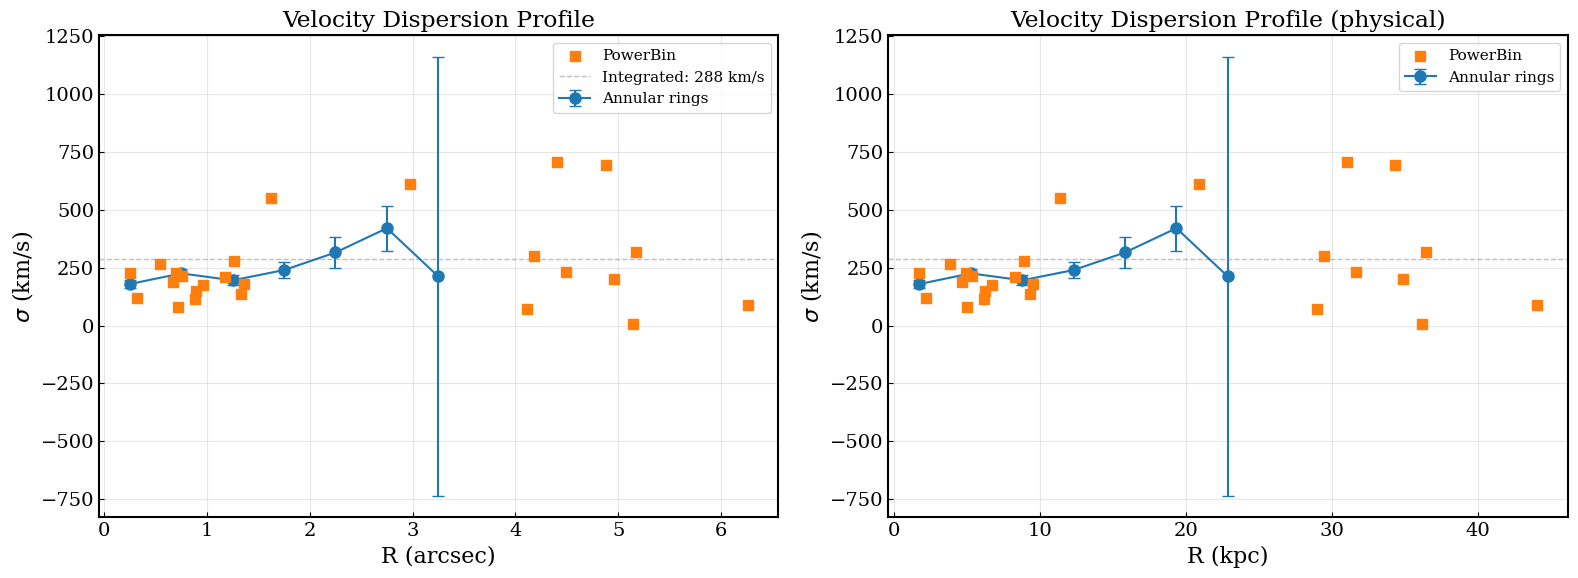

In [12]:
# Sigma(R) with bootstrap errors
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: arcsec
ax = axes[0]
ax.errorbar(annular_r_mid, sigma_annular,
            yerr=[sigma_boot_lo_ann, sigma_boot_hi_ann],
            fmt="o-", color="C0", capsize=4, markersize=8, label="Annular rings")
ax.errorbar(pb_r_mean, sigma_pb,
            yerr=[sigma_boot_lo_pb, sigma_boot_hi_pb],
            fmt="s", color="C1", capsize=3, markersize=7, label="PowerBin", zorder=5)

try:
    boot_int = np.load("../results/ppxf_bootstrap_errors_fsps.npz", allow_pickle=True)
    sigma_int = np.median(boot_int["sigma_original"])
    ax.axhline(sigma_int, color="gray", ls="--", lw=1, alpha=0.5,
              label=f"Integrated: {sigma_int:.0f} km/s")
except FileNotFoundError:
    pass

ax.set_xlabel("R (arcsec)")
ax.set_ylabel(r"$\sigma$ (km/s)")
ax.set_title("Velocity Dispersion Profile (bootstrap 16th-84th)")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# Right: kpc
ax = axes[1]
ax.errorbar(annular_r_mid * kpc_per_arcsec, sigma_annular,
            yerr=[sigma_boot_lo_ann, sigma_boot_hi_ann],
            fmt="o-", color="C0", capsize=4, markersize=8, label="Annular rings")
ax.errorbar(pb_r_mean * kpc_per_arcsec, sigma_pb,
            yerr=[sigma_boot_lo_pb, sigma_boot_hi_pb],
            fmt="s", color="C1", capsize=3, markersize=7, label="PowerBin", zorder=5)
try:
    ax.axhline(sigma_int, color="gray", ls="--", lw=1, alpha=0.5)
except NameError:
    pass

ax.set_xlabel("R (kpc)")
ax.set_ylabel(r"$\sigma$ (km/s)")
ax.set_title("Velocity Dispersion Profile (physical)")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../results/figures/sigma_radial_profile.png", dpi=300, bbox_inches="tight")
plt.show()


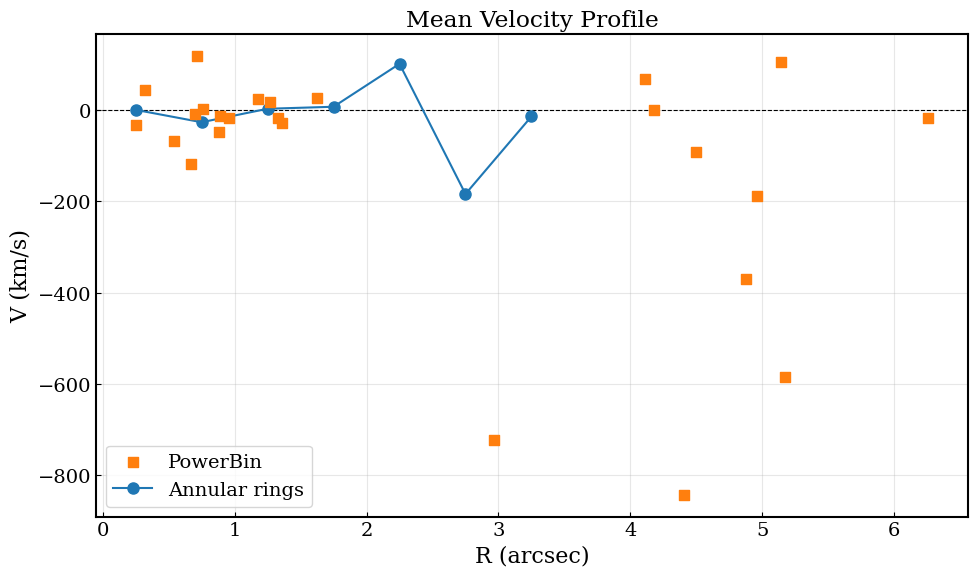

In [13]:
# Mean velocity profile (rotation curve)
fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(annular_r_mid, V_annular, fmt='o-', color='C0', capsize=4,
            markersize=8, label='Annular rings')
ax.scatter(pb_r_mean, V_pb, c='C1', s=60, marker='s', zorder=5, label='PowerBin')
ax.axhline(0, color='k', ls='--', lw=0.8)

ax.set_xlabel('R (arcsec)')
ax.set_ylabel('V (km/s)')
ax.set_title('Mean Velocity Profile')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Summary and comparison

In [18]:
print('=' * 60)
print('RADIAL VELOCITY DISPERSION PROFILE — AGEL0206')
print('=' * 60)
print(f'\nDeflector center: RA={ra_center:.6f}, Dec={dec_center:.6f}')
print(f'Scale: {kpc_per_arcsec:.2f} kpc/arcsec at z={z_defl}')
print(f'\nAnnular bins: {len(annular_spectra)} rings')
print(f'PowerBin: {n_bins_pb} bins (target S/N={target_sn})')

print(f'\nAnnular sigma(R):')
print(f'{"R (arcsec)":>10} {"R (kpc)":>8} {"sigma":>7} {"err":>5} {"N_spax":>7}')
for r, s, e, n in zip(annular_r_mid, sigma_annular, sigma_err_annular, annular_n_spax):
    print(f'{r:10.2f} {r*kpc_per_arcsec:8.1f} {s:7.0f} {e:5.0f} {n:7d}')

# Save results
np.savez('../results/radial_sigma_profile.npz',
         annular_r_mid=annular_r_mid,
         annular_r_kpc=annular_r_mid * kpc_per_arcsec,
         sigma_annular=sigma_annular,
         sigma_err_annular=sigma_err_annular,
         V_annular=V_annular,
         annular_n_spax=annular_n_spax,
         pb_r_mean=pb_r_mean,
         sigma_pb=sigma_pb,
         sigma_err_pb=sigma_err_pb,
         V_pb=V_pb,
         ra_center=ra_center,
         dec_center=dec_center,
         kpc_per_arcsec=kpc_per_arcsec,
         z_defl=z_defl)
print('\nSaved: ../results/radial_sigma_profile.npz')

RADIAL VELOCITY DISPERSION PROFILE — AGEL0206

Deflector center: RA=31.556084, Dec=-1.238189
Scale: 7.04 kpc/arcsec at z=0.675

Annular bins: 7 rings
PowerBin: 25 bins (target S/N=10)

Annular sigma(R):
R (arcsec)  R (kpc)   sigma   err  N_spax
      0.25      1.8     160    17       9
      0.75      5.3     217    18      26
      1.25      8.8     189    21      39
      1.75     12.3     238    37      42
      2.25     15.8     338    72      38
      2.75     19.4     475   103      32
      3.25     22.9     159   424       4

Saved: ../results/radial_sigma_profile.npz
